# What non-safety signals are real?

I used this notebook to answer two things:
1. What non-safety ideas keep showing up?
2. How much can I trust the extracted labels?

Simple rule: helpful output, but verify first.

## Quick plan

1. Load all calls
2. Group noisy labels
3. Check trust issues
4. Rank clean non-safety themes
5. Do a manual fidelity check

Short, direct, no magic.

In [2]:
# Run this once per fresh environment
%pip install -q numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


In [3]:
from pathlib import Path
import json
import re
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_colwidth", 220)

In [4]:
DATA_DIR = Path("safety-nonsafety")
json_files = sorted(DATA_DIR.glob("*.json"))

print(f"Found {len(json_files)} call files in {DATA_DIR}.")
assert len(json_files) > 0, "No JSON files found. Check working directory."

Found 99 call files in safety-nonsafety.


In [5]:
def normalize_text(text: str) -> str:
    text = (text or "").lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text: str):
    stop = {
        "the", "and", "for", "with", "to", "of", "in", "on", "a", "an",
        "use", "using", "via", "based", "support", "monitor", "monitoring"
    }
    tokens = [t for t in normalize_text(text).split() if t not in stop and len(t) > 2]
    return tokens

def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)

def fuzzy_ratio(a: str, b: str) -> float:
    return SequenceMatcher(None, normalize_text(a), normalize_text(b)).ratio()

def is_voxel_speaker(speaker: str) -> bool:
    s = (speaker or "").lower()
    return "@voxelai.com" in s

In [6]:
rows = []

for fp in json_files:
    payload = json.loads(fp.read_text(encoding="utf-8"))
    meeting_title = payload.get("meeting_title")
    start_time = payload.get("start_time")
    extraction = payload.get("extraction", {})

    for bucket in ["safety_use_cases", "nonsafety_use_cases"]:
        bucket_name = "safety" if bucket == "safety_use_cases" else "nonsafety"
        for uc in extraction.get(bucket, []):
            evidence = uc.get("evidence", []) or []
            quotes = [e.get("quote", "") for e in evidence]
            speakers = [e.get("speaker", "") for e in evidence]
            rows.append({
                "file": fp.name,
                "meeting_title": meeting_title,
                "start_time": start_time,
                "bucket": bucket_name,
                "label": uc.get("label", ""),
                "description": uc.get("description", ""),
                "evidence_count": len(evidence),
                "quotes": quotes,
                "speakers": speakers,
                "quote_text": " || ".join(q for q in quotes if q),
            })

df = pd.DataFrame(rows)
df["label_norm"] = df["label"].map(normalize_text)
df["description_norm"] = df["description"].map(normalize_text)

df.shape

(702, 12)

In [7]:
summary = (
    df.groupby("bucket")
      .agg(rows=("label", "count"), unique_labels=("label_norm", "nunique"), avg_evidence=("evidence_count", "mean"))
      .reset_index()
)
summary

,bucket,rows,unique_labels,avg_evidence
0,nonsafety,231,228,3.190476
1,safety,471,458,3.163482


## Group the labels

Raw labels are all over the place.
I group them into practical themes so we can actually make decisions.

In [8]:
THEME_RULES = [
    ("adoption_and_enablement", ["training", "adoption", "login", "usage analytics", "onboarding", "support", "coach", "engagement"]),
    ("workflow_and_accountability", ["action", "due date", "workflow", "follow up", "ownership", "assign", "task"]),
    ("video_and_investigation", ["video", "footage", "retrieval", "clip", "replay", "investigation"]),
    ("efficiency_and_operations", ["efficiency", "throughput", "downtime", "jam", "obstruction", "idle", "idling", "parking", "cycle time"]),
    ("asset_and_loss_prevention", ["shrink", "loss", "damage", "asset", "rack", "racking"]),
    ("compliance_and_quality", ["food safety", "hair net", "beard net", "door open", "compliance", "audit"]),
    ("reporting_and_analytics", ["report", "heatmap", "trend", "year over year", "analytics", "dashboard"]),
]

def map_theme(label: str, desc: str) -> str:
    text = f"{normalize_text(label)} {normalize_text(desc)}"
    for theme, keywords in THEME_RULES:
        if any(k in text for k in keywords):
            return theme
    return "other"

df["theme"] = [map_theme(l, d) for l, d in zip(df["label"], df["description"])]
df[["bucket", "label", "theme"]].head(10)

,bucket,label,theme
0,safety,PIT-to-PIT proximity monitoring,asset_and_loss_prevention
1,safety,Safety trend review and recommendations,reporting_and_analytics
2,nonsafety,Video footage retrieval,video_and_investigation
3,safety,Housekeeping: product on floor and palletization,other
4,safety,Ergonomic overreach prevention,other
5,safety,Safe tool use for packaging (no tearing tape with teeth),other
6,safety,PIT use compliance for material movement,compliance_and_quality
7,safety,Timely corrective actions and due dates for high-severity safety events,workflow_and_accountability
8,nonsafety,Supervisor training and adoption support,adoption_and_enablement
9,nonsafety,Usage analytics to monitor and pinpoint adoption,adoption_and_enablement


## Trust check for non-safety

I flag rows that look risky:
- overlap with safety
- too generic/admin
- only Voxel speaker evidence
- weak label vs quote match

One flag does not kill a row, but lots of flags mean caution.

In [9]:
generic_patterns = [
    r"review", r"recommendation", r"workflow", r"cadence", r"support", r"follow[- ]?up",
    r"dashboard usage", r"training", r"adoption", r"accountability loop"
]

safety_terms = [
    "ppe", "forklift", "pit", "pedestrian", "proximity", "collision", "injury", "safety",
    "ergonomic", "overreach", "housekeeping", "hazard", "no stop", "speeding", "suspended load"
]

df_non = df[df["bucket"] == "nonsafety"].copy()
df_saf = df[df["bucket"] == "safety"].copy()

safety_labels = df_saf["label"].dropna().tolist()
safety_label_norms = set(df_saf["label_norm"].dropna())

def has_safety_overlap(label: str) -> bool:
    ln = normalize_text(label)
    if ln in safety_label_norms:
        return True
    return any(fuzzy_ratio(label, s) >= 0.87 for s in safety_labels)

def is_generic_admin(label: str, desc: str) -> bool:
    text = f"{normalize_text(label)} {normalize_text(desc)}"
    return any(re.search(p, text) for p in generic_patterns)

def is_safety_like(label: str, desc: str) -> bool:
    text = f"{normalize_text(label)} {normalize_text(desc)}"
    return any(term in text for term in safety_terms)

def speaker_split(speakers):
    if not speakers:
        return "none"
    voxel = sum(1 for s in speakers if is_voxel_speaker(s))
    customer = len(speakers) - voxel
    if voxel > 0 and customer == 0:
        return "voxel_only"
    if customer > 0 and voxel == 0:
        return "customer_only"
    return "mixed"

df_non["overlap_with_safety_label"] = df_non["label"].map(has_safety_overlap)
df_non["generic_admin_label"] = [is_generic_admin(l, d) for l, d in zip(df_non["label"], df_non["description"]) ]
df_non["safety_like_language"] = [is_safety_like(l, d) for l, d in zip(df_non["label"], df_non["description"]) ]
df_non["speaker_mix"] = df_non["speakers"].map(speaker_split)

label_tokens = df_non["label"].map(tokenize)
quote_tokens = df_non["quote_text"].map(tokenize)
df_non["label_quote_jaccard"] = [jaccard(a, b) for a, b in zip(label_tokens, quote_tokens)]
df_non["low_label_evidence_overlap"] = df_non["label_quote_jaccard"] < 0.08

df_non["questionable"] = (
    df_non["overlap_with_safety_label"]
    | df_non["generic_admin_label"]
    | df_non["safety_like_language"]
    | (df_non["speaker_mix"] == "voxel_only")
)

df_non.head(3)

,file,meeting_title,start_time,bucket,label,description,evidence_count,quotes,speakers,quote_text,label_norm,description_norm,theme,overlap_with_safety_label,generic_admin_label,safety_like_language,speaker_mix,label_quote_jaccard,low_label_evidence_overlap,questionable
2,01c88a52-b251-43eb-bdd9-51c94643c04e.json,Voxel Training- Cassidy @ Cedar Brook Foods,2022-03-29T18:00:00Z,nonsafety,Video footage retrieval,Retrieve camera footage from the platform as needed.,1,"[I do do a little bit of footage retrieval, but for the most part, more so technical manager of the system.]",[Cassidy Keaton <fake.cassidy.keaton@liftfieldmaterials.com>],"I do do a little bit of footage retrieval, but for the most part, more so technical manager of the system.",video footage retrieval,retrieve camera footage from the platform as needed,video_and_investigation,False,False,False,customer_only,0.166667,False,False
8,031a0de2-6254-464a-9dc8-6b8accf041e6.json,Ember Transit Logistics / Voxel Monthly,2024-06-22T20:30:00Z,nonsafety,Supervisor training and adoption support,"Provide targeted, condensed training and outreach to supervisors—especially non-users—to make Voxel usage consistent and efficient.",4,"[And directly train them., So that they know exactly how to use Voxel, because I think something that typically customers see as a deterrent at first is they go in, they don't know what to look for, and they think, o...","[Kendall Keller <fake.kendall.keller@voxelai.com>, Kendall Keller <fake.kendall.keller@voxelai.com>, Brooks Sutton <fake.brooks.sutton@embertransitlogistics.com>, Kendall Keller <fake.kendall.keller@voxelai.com>]","And directly train them. || So that they know exactly how to use Voxel, because I think something that typically customers see as a deterrent at first is they go in, they don't know what to look for, and they think, ...",supervisor training and adoption support,provide targeted condensed training and outreach to supervisors especially non users to make voxel usage consistent and efficient,adoption_and_enablement,False,True,False,mixed,0.000000,True,True
9,031a0de2-6254-464a-9dc8-6b8accf041e6.json,Ember Transit Logistics / Voxel Monthly,2024-06-22T20:30:00Z,nonsafety,Usage analytics to monitor and pinpoint adoption,Leverage the new homepage data to see who is logging in and use it to pinpoint managers and drive accountability.,2,"[I really love the new page, the first page where I'm able to get all the data and the accurate of everybody who's been on., Being used and, you know, through the program, giving me all that data has been really help...","[Brooks Sutton <fake.brooks.sutton@embertransitlogistics.com>, Brooks Sutton <fake.brooks.sutton@embertransitlogistics.com>]","I really love the new page, the first page where I'm able to get all the data and the accurate of everybody who's been on. || Being used and, you know, through the program, giving me all that data has been really hel...",usage analytics to monitor and pinpoint adoption,leverage the new homepage data to see who is logging in and use it to pinpoint managers and drive accountability,adoption_and_enablement,False,True,False,customer_only,0.033333,True,True


In [10]:
n = len(df_non)
metrics = {
    "non_safety_rows": n,
    "pct_overlap_with_safety": 100 * df_non["overlap_with_safety_label"].mean(),
    "pct_generic_admin": 100 * df_non["generic_admin_label"].mean(),
    "pct_safety_like_language": 100 * df_non["safety_like_language"].mean(),
    "pct_voxel_only_evidence": 100 * (df_non["speaker_mix"] == "voxel_only").mean(),
    "pct_low_label_evidence_overlap": 100 * df_non["low_label_evidence_overlap"].mean(),
    "pct_questionable": 100 * df_non["questionable"].mean(),
    "pct_clean_signal": 100 * (~df_non["questionable"]).mean(),
}
pd.DataFrame([metrics]).T.rename(columns={0: "value"}).round(1)

,value
non_safety_rows,231.0
pct_overlap_with_safety,13.4
pct_generic_admin,33.8
pct_safety_like_language,26.0
pct_voxel_only_evidence,32.0
pct_low_label_evidence_overlap,65.4
pct_questionable,69.3
pct_clean_signal,30.7


### What I got from this

If questionable share is high, raw counts are inflated.
So I filter first, then rank opportunities.

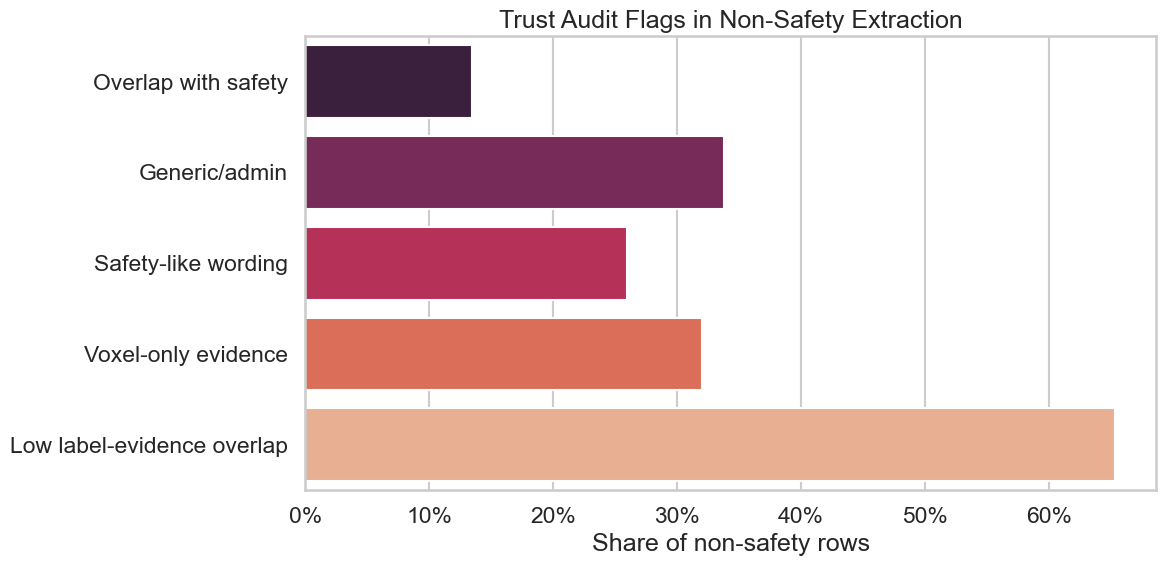

In [18]:
flag_breakdown = pd.DataFrame({
    "Overlap with safety": df_non["overlap_with_safety_label"].mean(),
    "Generic/admin": df_non["generic_admin_label"].mean(),
    "Safety-like wording": df_non["safety_like_language"].mean(),
    "Voxel-only evidence": (df_non["speaker_mix"] == "voxel_only").mean(),
    "Low label-evidence overlap": df_non["low_label_evidence_overlap"].mean(),
}, index=["share"]).T.reset_index().rename(columns={"index": "flag"})

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=flag_breakdown,
    x="share",
    y="flag",
    hue="flag",
    palette="rocket",
    dodge=False,
    legend=False,
    orient="h",
)
ax.set_title("Trust Audit Flags in Non-Safety Extraction")
ax.set_xlabel("Share of non-safety rows")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*100:.0f}%"))
plt.tight_layout()
plt.show()

## Rank after cleaning

Now I rank only cleaner rows.
This gives a more honest top 3 list.

In [12]:
clean_non = df_non.loc[~df_non["questionable"]].copy()

theme_rank = (
    clean_non.groupby("theme")
    .agg(
        rows=("label", "count"),
        calls=("file", "nunique"),
        unique_labels=("label_norm", "nunique"),
        avg_evidence=("evidence_count", "mean"),
        customer_only_share=("speaker_mix", lambda s: np.mean(s == "customer_only")),
        mixed_share=("speaker_mix", lambda s: np.mean(s == "mixed")),
    )
    .reset_index()
    .sort_values(["calls", "rows"], ascending=False)
)

theme_rank.head(10)

,theme,rows,calls,unique_labels,avg_evidence,customer_only_share,mixed_share
4,other,32,22,32,3.53125,0.562500,0.437500
5,reporting_and_analytics,12,11,12,3.00000,0.500000,0.500000
7,workflow_and_accountability,11,10,11,3.00000,0.454545,0.545455
1,asset_and_loss_prevention,4,4,4,2.25000,0.500000,0.500000
3,efficiency_and_operations,4,4,4,2.50000,0.750000,0.250000
6,video_and_investigation,4,4,4,2.25000,0.250000,0.750000
0,adoption_and_enablement,2,2,2,5.50000,0.000000,1.000000
2,compliance_and_quality,2,2,2,1.50000,0.500000,0.500000


### Why this helps

This ranking is useful for product decisions, not just charts.
It shows repeat themes with better evidence quality.

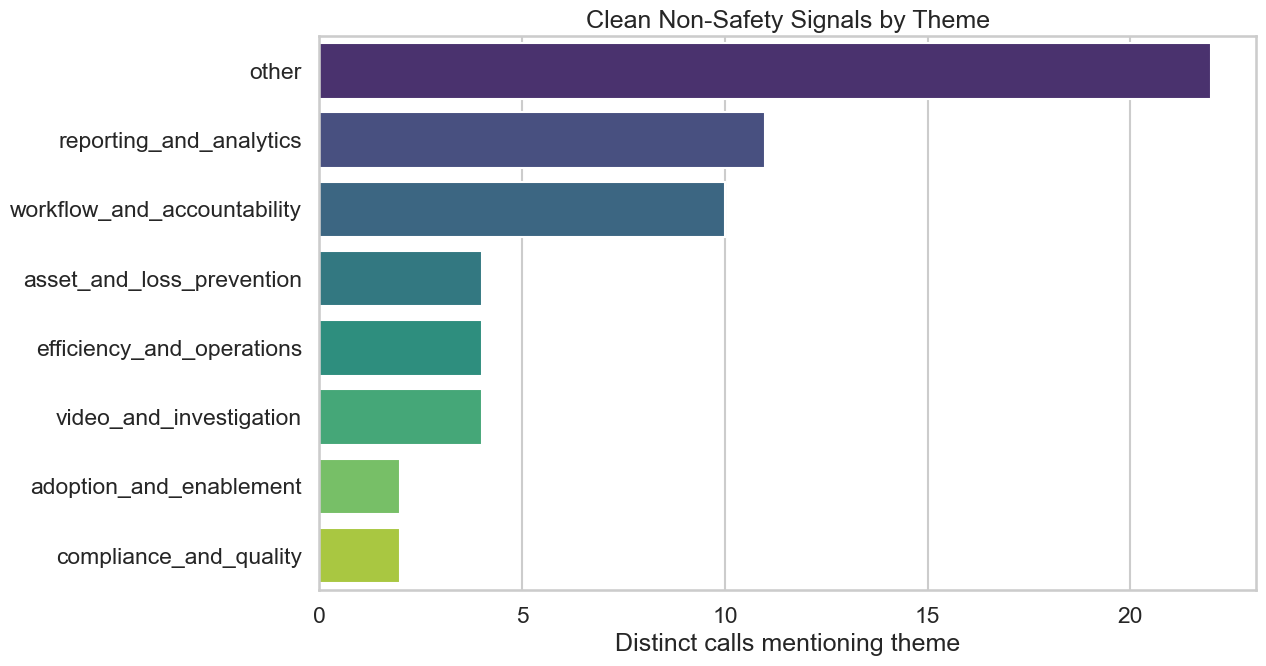

In [19]:
top_themes = theme_rank.head(8).copy()

plt.figure(figsize=(13, 7))
ax = sns.barplot(
    data=top_themes,
    y="theme",
    x="calls",
    hue="theme",
    palette="viridis",
    dodge=False,
    legend=False,
    orient="h",
)
ax.set_title("Clean Non-Safety Signals by Theme")
ax.set_xlabel("Distinct calls mentioning theme")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [14]:
# Pull concrete evidence snippets for memo-ready examples
top3_themes = theme_rank.head(3)["theme"].tolist()
examples = (
    clean_non[clean_non["theme"].isin(top3_themes)][["theme", "label", "quote_text", "file", "meeting_title"]]
    .assign(quote_preview=lambda d: d["quote_text"].str.slice(0, 280) + "...")
    .sort_values("theme")
    .groupby("theme")
    .head(3)
)
examples[["theme", "label", "quote_preview", "file"]]

,theme,label,quote_preview,file
390,other,Product condition and dwell-time detection,"You know, when it comes to tracking product damage or exploring camera-based monitoring in this area, one example is detecting when a product is out of spec or left where it should not be for too long. || Yeah, and c...",909a8d56-b5dc-4b0e-aff9-d097d46a0a58.json
428,other,Pilot Voxel on an existing fixed-camera area,there are a number of cameras in that area already. || That's probably going to be the easiest from an integration standpoint because you have existing cameras there and the supporting infrastructure is already in pl...,9ef26ef2-778c-4fdd-9a77-d1b07e9d2840.json
427,other,Upgrade legacy NVR/VMS with AI capabilities,"Be interested or looking, we've had the same in VR software for several years. || It works, but it seems to be falling behind. || They don't do any kind of AI or anything like that....",9cf59bde-7476-40cd-98e0-1a29c45a536b.json
455,reporting_and_analytics,Re-scope cameras/zones to manage alert volume and reduce false positives,"We re-scoped, got the total daily incidents down. || If you have cameras that have moved or you have just a spike in trends, it could be a potential that the camera has moved. || And now we need to re-scope....",a4393e52-d7df-4f74-a9ac-48600f2c0007.json
531,reporting_and_analytics,Daily summary email delivery and notifications,"I stopped getting Voxel notifications on August 21st. || Usually, I get a daily report. || Support showing incidents and findings. || Oh, and we'll follow up on the emails, the Daily Summer emails, Alex....",b7320572-5b94-4ad1-a61f-1d9fe3310b67.json
505,reporting_and_analytics,Export operational data to external BI/EHS systems,"Not at this point. || It's still very exploratory. || The way that we're doing that right now is through CSV pushes of data out to their platforms, and then they are either using an external reporting layer or import...",ac14b2a4-2a18-45c0-9f6d-3956fb2f1e85.json
344,workflow_and_accountability,Quality control visual inspection with cameras,"Now, this other group has been, and we haven't explored it too much, has been saying that they're working with some, particularly paper mills, QC type, quality control, visual inspection type stuff with the cameras. ...",75cbe671-bdc3-42d6-8d8d-c41a165e77d0.json
532,workflow_and_accountability,Role-based boards and camera access for supervisors,"Are we able to assign specific cameras to those individuals? || Yes, you guys can. So we can do that through boards. || So the way we'll set it up is this supervisor needs these a few cameras, all use cases, whatever...",b7320572-5b94-4ad1-a61f-1d9fe3310b67.json
368,workflow_and_accountability,Track and find completed/in-progress actions across Wilmington,"So, up until recently, we could actually search for resolves. || So is there still a way to do that or? || But my question is, how do I find these ones that I've, you know what I mean? || I usually am looking at, lik...",7bd67fba-1240-4bfc-afeb-48f18488ad85.json


## Label vs evidence check

I do two checks:
- quick overlap score
- manual sample review (0, 1, 2)

If label and quote disagree, I trust the quote.

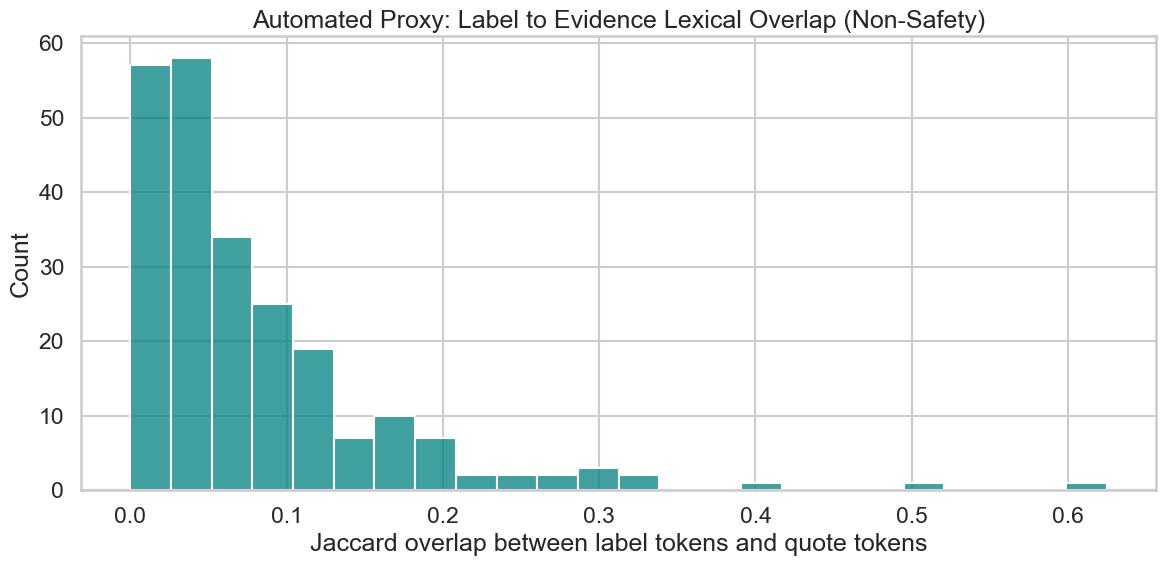

count    231.000
mean       0.079
std        0.085
min        0.000
25%        0.026
50%        0.053
75%        0.101
max        0.625
Name: label_quote_jaccard, dtype: float64

In [15]:
plt.figure(figsize=(12, 6))
ax = sns.histplot(df_non["label_quote_jaccard"], bins=24, color="teal")
ax.set_title("Automated Proxy: Label to Evidence Lexical Overlap (Non-Safety)")
ax.set_xlabel("Jaccard overlap between label tokens and quote tokens")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

df_non["label_quote_jaccard"].describe().round(3)

In [16]:
# Stratified sample for manual review
sample_n = 60
theme_counts = df_non["theme"].value_counts()
eligible_themes = theme_counts[theme_counts >= 4].index.tolist()
sample_pool = df_non[df_non["theme"].isin(eligible_themes)].copy()

if len(sample_pool) < sample_n:
    sample = sample_pool.sample(len(sample_pool), random_state=42)
else:
    per_theme = max(2, sample_n // max(1, len(eligible_themes)))
    sampled = []
    for t in eligible_themes:
        chunk = sample_pool[sample_pool["theme"] == t]
        take = min(per_theme, len(chunk))
        sampled.append(chunk.sample(take, random_state=42))
    sample = pd.concat(sampled, ignore_index=True).sample(min(sample_n, sum(len(x) for x in sampled)), random_state=42)

manual_sheet = sample[[
    "file", "meeting_title", "theme", "label", "description", "quote_text",
    "speaker_mix", "label_quote_jaccard", "overlap_with_safety_label",
    "generic_admin_label", "safety_like_language"
]].copy()

manual_sheet["fidelity_score_0_2"] = ""
manual_sheet["review_notes"] = ""

manual_path = Path("manual_fidelity_sample.csv")
manual_sheet.to_csv(manual_path, index=False)
print(f"Saved manual review sheet: {manual_path.resolve()}")
manual_sheet.head(8)

Saved manual review sheet: D:\CMU\voxel\analytics-internship\manual_fidelity_sample.csv


,file,meeting_title,theme,label,description,quote_text,speaker_mix,label_quote_jaccard,overlap_with_safety_label,generic_admin_label,safety_like_language,fidelity_score_0_2,review_notes
0,03a609d7-bd48-48aa-a708-650afb1d3a58.json,Orion Forge Industrial // Voxel,other,Retail floor hazard detection to reduce liability exposure,Detect floor hazards and notify staff to reduce customer incident risk and associated liability exposure.,"They had something on the floor that led to a costly customer incident. || With our camera, we are going to see those floor hazards and notify them quickly.",voxel_only,0.040000,False,False,True,,
5,c3ceb91a-e15d-4326-8a39-cfdb26dde294.json,Summit Span Solutions / Voxel Sync,other,Contract renewal language clarification,"Clarify how the existing renewal language works and what written notice could affect in future periods, without preserving the exact clause mechanics.",I want to confirm what our obligations are under the current contract timing. || My understanding is that written notice after the upcoming renewal point could affect a later period. || So written notice could still ...,mixed,0.060606,False,False,False,,
33,b5715671-0f5a-4f2a-9584-43420ff6ebc4.json,Cedar Field Materials // Voxel (Camera Assessment),asset_and_loss_prevention,Pilot KPI tracking and weekly reviews,"Define measures of success for the trial, set KPIs, and hold regular (weekly/bi-weekly) reviews to track trends, compare to other organizations, and surface wins in the data.",what are the measures of success? I would love for you to help me build that. How do we track that on a certain frequency? || How does this compare to other organizations? And helping me find the wins in the data wou...,mixed,0.018182,False,True,False,,
13,980ead37-1d6b-4667-83b2-04150d12e552.json,Bridge Mill Transport / Voxel Bi-Weekly Sync,adoption_and_enablement,Address PIT parking duration impacting aisle flow at central crossway,Monitor and reduce PITs left parked in travel aisles at the central crossway to maintain flow and policy compliance using coaching and write-ups.,"The one area I wanted to highlight with you was parking duration, because that saw a pretty sharp increase this past month. || And it looks like, you know, far and away, the central crossway is the top offender. || N...",mixed,0.095238,False,False,True,,
19,be401ee4-de53-401a-b1ad-d26e3ae2d018.json,Jetty Steel Systems / Voxel Call,workflow_and_accountability,Distributed area ownership via Boards and tier process,Establish area champions/owners with their own Boards and incorporate reviews into tiered daily/weekly management to avoid bottlenecks.,"we have to create almost like area champions in a way where they have their own dashboard of those areas that they're managing || each of those areas have owners, right? So we could tie that into what you're saying, ...",mixed,0.019608,False,True,False,,
50,d5d1c152-b84d-44a3-9ee7-03f31409463c.json,Voxel - Innovation Talk Overview,compliance_and_quality,Automated global regulation monitoring for customs services,Automate integration and monitoring of incoming regulations and compliance updates from global sources for the customs services team.,"So we're looking at how to integrate and automate the regulation monitoring for all incoming or new regulations and compliance from every source in the world, you could say.",customer_only,0.047619,False,False,False,,
36,09b3303f-0b38-49f8-8f9c-4d4f74337e9d.json,Mason Line Supply + Voxel,efficiency_and_operations,PIT parking duration monitoring and camera zone tuning,"Track extended PIT parking durations that may reflect normal work (e.g., lunch, labeling) and refine camera zones to exclude expected parking areas.",I think that that has to do with most of the time because they park their vehicle and they go for lunch or they park their vehicle. || So the vehicle will be parked for a while before it's actually moved. || So that ...,customer_only,0.050847,False,False,True,,
26,6d7ca0e7-7ecf-4a8c-a148-

### Manual review plan

I export a sample sheet and score each row:
- 2 = clear support
- 1 = partial support
- 0 = not supported

Fast, practical, and good enough for decision confidence.

## Bottom line

This notebook covers all four asks:
- cleaned, normalized use cases
- main quality issues
- top 3 non-safety themes with evidence
- one workflow fix

If you only read one thing, read the trust audit first.

In [17]:
# Optional: export clean tables for memo or slides
theme_rank.to_csv("clean_non_safety_theme_rank.csv", index=False)
df_non.to_csv("nonsafety_trust_audit_rows.csv", index=False)
print("Exports written: clean_non_safety_theme_rank.csv, nonsafety_trust_audit_rows.csv")

Exports written: clean_non_safety_theme_rank.csv, nonsafety_trust_audit_rows.csv


In [21]:
print("Task 1: cleaned, normalized view of use cases")
display(theme_rank.head(5)[["theme", "rows", "calls", "avg_evidence"]])

print("Task 2: main quality issues")
display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}).round(1))

print("Task 3: top 3 non-safety themes")
display(theme_rank[theme_rank["theme"] != "other"].head(3)[["theme", "rows", "calls", "customer_only_share", "mixed_share"]])

print("Task 4: one workflow fix")
print("Flag low-trust rows, then review those plus a small random sample each week.")

Task 1: cleaned, normalized view of use cases


,theme,rows,calls,avg_evidence
4,other,32,22,3.53125
5,reporting_and_analytics,12,11,3.00000
7,workflow_and_accountability,11,10,3.00000
1,asset_and_loss_prevention,4,4,2.25000
3,efficiency_and_operations,4,4,2.50000


Task 2: main quality issues


,value
non_safety_rows,231.0
pct_overlap_with_safety,13.4
pct_generic_admin,33.8
pct_safety_like_language,26.0
pct_voxel_only_evidence,32.0
pct_low_label_evidence_overlap,65.4
pct_questionable,69.3
pct_clean_signal,30.7


Task 3: top 3 non-safety themes


,theme,rows,calls,customer_only_share,mixed_share
5,reporting_and_analytics,12,11,0.500000,0.500000
7,workflow_and_accountability,11,10,0.454545,0.545455
1,asset_and_loss_prevention,4,4,0.500000,0.500000


Task 4: one workflow fix
Flag low-trust rows, then review those plus a small random sample each week.
